In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)
sys.dont_write_bytecode = True

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import DRT_PATH, TP4_PATH, MODEL_PATH, ROCK_PATH

ABS_PATH = PROJECT_ROOT + DRT_PATH + TP4_PATH
LOAD_MODEL = PROJECT_ROOT + MODEL_PATH + ROCK_PATH

model_name = "Rock1.blend"
load_data_bound = ABS_PATH + "./files/data.csv"
load_initial = ABS_PATH + "./files/initial.csv"
fem_train = ABS_PATH + "./files/fem_solution.csv"
mesh_point_path = ABS_PATH + "./files/mesh_points.csv"

fig_dir = "figures/"
loss_fig = ABS_PATH + fig_dir + "loss.png"

In [ ]:
# Import
import torch
import pandas as pd
import matplotlib.pyplot as plt

from modelaquisition.bl2pina import Blend2Pina
from pina.solvers.pinns import RBAPINN
from pina.callbacks import MetricTracker
from pina.operators import grad, laplacian
from pina.model import ResidualFeedForward
from pina import LabelTensor, Trainer, Plotter
from pina.condition import Condition, Equation
from pina.problem import SpatialProblem, TimeDependentProblem
from pytorch_lightning.callbacks import StochasticWeightAveraging

In [4]:
torch.set_default_dtype(torch.float64)

In [5]:
# Network variables
swa_lr = 5e-4
lear_rate = 1e-3
decay_rt = 1e-8

# Solver variables
epochs=3_000
batch=None
acc_str = 'gpu'

ipt_var = 4
out_var = 1
lay = 2
neur = 200

# Num points
num_train = 500
bound_points = 10_000

## Definizione del problema tramite il modulo `Problem` di PINA

Consideriamo il modello di diffusione del calore

$$
\begin{equation}
  \begin{cases}
    \frac{\partial T}{\partial t} \left( t, x, y, z \right) - \Delta T \left( t, x, y, x \right) = 0 & \left( t, x, y, z \right) \in \left[0, 1 \right] \times \Omega \\
    T \left( 0, x, y, z \right) = T_0 & \left( x, y, z \right) \in \Omega\\
    T \left( t, x, y, z \right) = \mathrm{data} & \left(t, x, y, z \right) \in \left(0, 1 \right] \times \partial \Omega
  \end{cases}
  \tag{1}
\end{equation}
$$

A tale scopo carichiamo i dati approssimati tramite una NN relativi alle condizioni iniziali e al contorno e definiamo il problema tramite la classe `Problem` di **PINA**.

In [6]:
rock = Blend2Pina(LOAD_MODEL + model_name)

rock_int = rock.intern(time_interval=[0, 1])
rock_bound = rock.boundary(time_interval=[0, 1])

Read blend: "/home/cvalentino/SissaUnisaDraftCodes/models/rock/Rock1.blend"


In [7]:
df = pd.read_csv(load_data_bound, sep=";", index_col=0)

input_pts = df.iloc[:, :4].values
output_pts = df.iloc[:, -1].values

input_pts = LabelTensor(
    x=torch.tensor(input_pts, dtype=torch.float64),
    labels=['x', 'y', 'z', 't']
)
output_pts = LabelTensor(
    x=torch.reshape(torch.tensor(output_pts, dtype=torch.float64), (output_pts.shape[0], 1)),
    labels=['u']
)

In [8]:
initial_cond = torch.tensor(
    pd.read_csv(load_initial, sep=";", index_col=0).values.tolist()[0][0]
)

In [9]:
class Heat(SpatialProblem, TimeDependentProblem):

    input_variables = ['x','y','z','t']
    output_variables = ['u']
    spatial_domain = rock_int.spatial_domain
    temporal_domain = rock_int.temporal_domain

    # Residual
    @staticmethod
    def residual(input_, output_):
        u_t = grad(output_, input_, components=['u'], d=['t'])
        my_lapl = laplacian(output_, input_, components=['u'], d=['x', 'y', 'z'])
        return u_t - my_lapl
    
    conditions = {
        'Omega' : Condition(
            location=rock_int,
            equation=Equation(residual)
        ),
        'data' : Condition(
            input_points=input_pts.extract(['x','y','z','t']),
            output_points=output_pts
        )
    }

problem = Heat()

In [10]:
df_train_tot = pd.read_csv(fem_train, sep=";", index_col=False).iloc[:, :4]

df_train = df_train_tot.sample(num_train, replace=False)

samples_train = LabelTensor(
    torch.tensor(df_train.values),
    problem.input_variables
)

In [11]:
# Discretizzazione del contorno e del dominio
problem.discretise_domain(
    n=1,
    mode='random',
    locations=['Omega']
)
problem.input_pts['Omega'] = samples_train

In [12]:
class HardMLP(torch.nn.Module):

    def __init__(self, T_initial, *args, **kwargs):
        super().__init__()
        self.T_initial = T_initial

        self.layers = ResidualFeedForward(*args, **kwargs)

    # Nel metodo forward implementiamo il vincolo rigido
    def forward(self, x):
        return self.T_initial + x.extract("t")*self.layers(x)

In [ ]:
# Modello
model = HardMLP(
    T_initial=initial_cond,
    input_dimensions=ipt_var,
    output_dimensions=out_var,
    n_layers=lay,
    inner_size=neur
)
# Solver
pinn=RBAPINN(
    problem=problem,
    model=model,
    optimizer_kwargs={
        'lr' : lear_rate,
        'weight_decay' : decay_rt
    },
)

# Trainer
trainer=Trainer(
    solver=pinn,
    max_epochs=epochs,
    batch_size=None,
    accelerator=acc_str,
    precision='64-true',
    callbacks=[MetricTracker(), StochasticWeightAveraging(swa_lrs=swa_lr)]
)

# Addestramento
trainer.train()

[michael-Alienware-Aurora-R15:12354] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/4087152640/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:12354] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/cvalentino/miniconda3/envs/dtsu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable Te

Epoch 2999: 100%|██████████| 2/2 [00:00<00:00, 63.64it/s, v_num=0, Omega_loss=7.15e-5, mean_loss=0.0124, data_loss=0.013]  

`Trainer.fit` stopped: `max_epochs=3000` reached.


Epoch 2999: 100%|██████████| 2/2 [00:00<00:00, 57.88it/s, v_num=0, Omega_loss=7.15e-5, mean_loss=0.0124, data_loss=0.013]


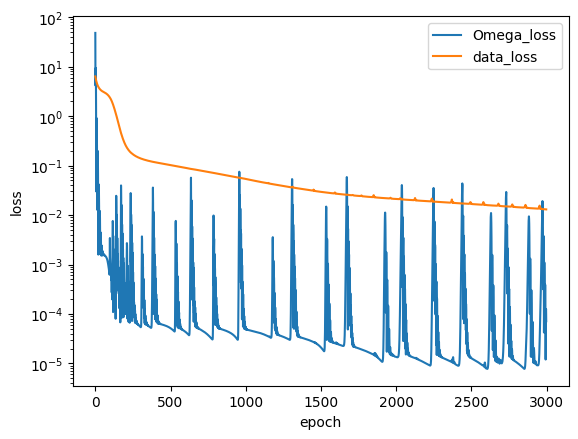

In [14]:
my_pl = Plotter()

my_pl.plot_loss(
    trainer=trainer,
    metrics=['Omega_loss'],
    label='Omega_loss',
    logy=True
)

my_pl.plot_loss(
    trainer=trainer,
    metrics=['data_loss'],
    label='data_loss',
    logy=True
)

plt.savefig(loss_fig, transparent=True)
plt.show()

In [15]:
torch.save(model.state_dict(), ABS_PATH + f"models/model_L{lay}_N{neur}_EP{epochs}.pth")

In [16]:
num_temp_points = 101
h = 1/(num_temp_points-1)

mesh_points = torch.tensor(
    pd.read_csv(mesh_point_path, sep=";", index_col=None).values
)
num_mesh_points = mesh_points.shape[0]

total_points = torch.zeros((num_temp_points*num_mesh_points, len(problem.input_variables)))

sol = torch.zeros((num_mesh_points, num_temp_points))

In [17]:
for idx in range(num_temp_points):
    t = idx*h
    points = LabelTensor(
        torch.cat(
            [mesh_points, t*torch.ones((num_mesh_points, 1))],
            axis=-1
        ),
        labels=problem.input_variables
    )
    sol[:, idx] = pinn.neural_net(points).tensor.detach().reshape(num_mesh_points,)

In [18]:
sol = sol.numpy()

df = pd.DataFrame(
    data=sol
)

df.to_csv("./files/pinn_solution.csv", sep=";", index=None, index_label=None)